In [1]:
import requests
import numpy as np
import time
'''
ssh -L 8080:localhost:8080 mbot@67.194.41.119
'''
# --- CONFIGURATION ---
ROBOT_IP = "localhost"#"67.194.41.119"  # <--- REPLACE THIS with the Pi's IP
PORT=8080
URL_IMG = f"http://{ROBOT_IP}:{PORT}/image.jpg"
URL_CMD = f"http://{ROBOT_IP}:{PORT}/control"

def send_command(linear, angular):
    """Sends a movement command and ignores response latency."""
    try:
        # Fire and forget (timeout is short so we don't freeze UI)
        requests.post(URL_CMD, json={"linear": linear, "angular": angular}, timeout=0.2)
        print(f" > Command sent: Lin={linear}, Ang={angular}")
    except requests.exceptions.ReadTimeout:
        pass # Expected if we set timeout very low
    except Exception as e:
        print(f" ! Command Error: {e}")

def get_image():
    """Fetches image and profiles the network latency."""
    print(" [..] Requesting frame...", end="", flush=True)
    
    start_time = time.perf_counter()  # Start Clock
    
    try:
        resp = requests.get(URL_IMG, timeout=3)
        if resp.status_code == 200:
            # Decode the raw bytes into an OpenCV image
            image_bytes = np.frombuffer(resp.content, np.uint8)
            
            
            end_time = time.perf_counter() # Stop Clock
            latency_ms = (end_time - start_time) * 1000
            
            print(f" OK! Latency: {latency_ms:.2f} ms")
            return image_bytes
        else:
            print(f" Fail (Status {resp.status_code})")
    except Exception as e:
        print(f" Error: {e}")
    return None
from PIL import Image
from io import BytesIO
def get_image_numpy():
    img = Image.open(BytesIO(get_image()))
    img = np.rot90(img, 2)
    return img

In [2]:
from utils.vlm_worker import VLMWorker
import matplotlib.pyplot as plt

from inference_main import CONVO_TURN_TEMPLATE
from utils.inference_core import substitute_convo_template

 [..] Requesting frame... OK! Latency: 720.53 ms


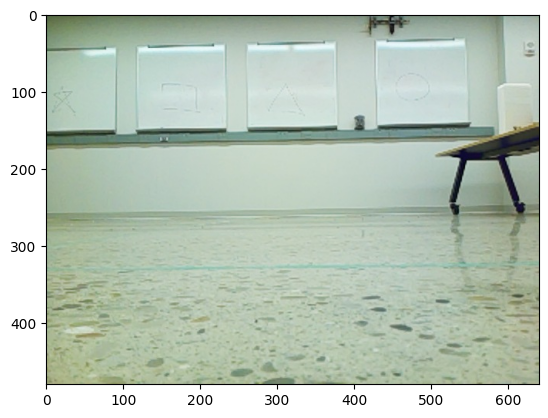

In [3]:

plt.imshow(get_image_numpy())

In [4]:
action_space_list=["stop","forward","left","right","back"]
worker = VLMWorker(model_id='Phyllis1/qwen3_sft_sft_sparse_03drop_single_action_20260103_210803_ckpt10800',
                   attn_implementation="sdpa",
                   dtype='float16',
                   vocab = action_space_list,
                   use_sparse=True
)


Loading Phyllis1/qwen3_sft_sft_sparse_03drop_single_action_20260103_210803_ckpt10800 with sparsifying patch...


In [ ]:
import textwrap
SYSTEM_PROMPT_TEMPLATE= textwrap.dedent("""\
You are a visual navigation agent tasked with finding "$goal" in an unknown environment.
You will receive a sequence of observations showing your movement history up to the current moment.

**Action Space:**
$action_space_str

**Your Mission:**
1. Analyze the observation history to understand your current location and orientation.
2. Select the next discrete action to navigate efficiently towards the goal.

**Critical Constraints:**
* **Collision Detection:** If your previous action was **forward** but the visual observation did not change significantly, you have collided. You MUST turn or move away immediately. Do not keep pushing forward.
* **Success Condition:** Output **stop** ONLY when the target is plainly in view, centered, and within 1 meter (close enough to touch).

**Hints:**
$hints
**Output Format:**
Respond with the selected action inside double asterisks.
""")



CONVO_START_TEMPLATE_CUSTOM = [
    {
        "role": "user",
        "content": [ # Placeholder for the pixel data
            {"type": "text", "text": SYSTEM_PROMPT_TEMPLATE},
        ],
    },
    {
        "role": "user",
        "content": [ # Placeholder for the pixel data
            {"type": "image"}
        ],
    },
    {
        "role": "assistant",
        "content":[
            {"type":"text","text": "**forward**"} # placeholder action to infer logprob during forward pass
        ]
    }
]
from inference_main import CONVO_START_TEMPLATE

worker.reset()
messages = substitute_convo_template(CONVO_START_TEMPLATE,{"goal_name":"power outlet",
                                                           "action_space_str":"[stop, forward, left, right, back]",
                                                           "hints":"it right in front of you at the start, just obscured. circumnavigate the obstacles."})
image = get_image_numpy()
images = [image]

 [..] Requesting frame... OK! Latency: 749.73 ms


keeping 300/300
 > Command sent: Lin=0, Ang=0.4
agent chose: left
 [..] Requesting frame... OK! Latency: 701.06 ms
keeping 264/300
 > Command sent: Lin=0, Ang=0.4
agent chose: left
 [..] Requesting frame... OK! Latency: 709.09 ms
keeping 260/300
 > Command sent: Lin=0, Ang=0.4
agent chose: left
 [..] Requesting frame... OK! Latency: 711.93 ms
keeping 251/300
 > Command sent: Lin=0, Ang=-0.4
agent chose: right
 [..] Requesting frame... OK! Latency: 705.16 ms
keeping 187/300
 > Command sent: Lin=0.1, Ang=0
agent chose: forward
 [..] Requesting frame... OK! Latency: 729.34 ms
keeping 231/300
 > Command sent: Lin=0.1, Ang=0
agent chose: forward
 [..] Requesting frame... OK! Latency: 711.44 ms
keeping 169/300
 > Command sent: Lin=0.1, Ang=0
agent chose: forward
 [..] Requesting frame... OK! Latency: 714.21 ms
keeping 168/300
 > Command sent: Lin=0.1, Ang=0
agent chose: forward
 [..] Requesting frame... OK! Latency: 703.99 ms
keeping 176/300
 > Command sent: Lin=0.1, Ang=0
agent chose: forwa

KeyboardInterrupt: 

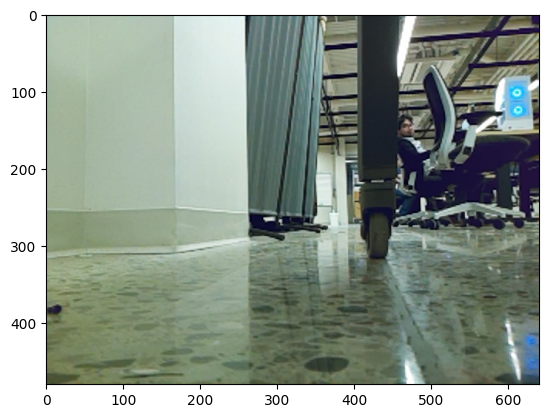

In [ ]:
while True:
    action_probs = worker.infer_probs(messages,[Image.fromarray(image)])
    action_id = np.random.choice(len(action_probs),p=action_probs) # sampling
    plt.imshow(image)
    # print(action_id)
    chosen_action = action_space_list[action_id]
    if action_id == 1:
        send_command(0.1,0)
    if action_id == 2:
        send_command(0,0.5)
    if action_id == 3:
        send_command(0,-0.5)
    if action_id == 4:
        send_command(-0.2,0.0)
    if action_id == 0:
        print("agent proposing stop!")
        decision = input("approve? y/n")
        if decision == 'y':
            break
        else:
            import random
            action_id = random.choice([2,3])
    print(f"agent chose: {chosen_action}")
    messages = substitute_convo_template(CONVO_TURN_TEMPLATE,{"action":chosen_action})
    image = get_image_numpy()
    images.append(image)


In [7]:
episode = np.array(images)
np.save('nav_episode',episode)